In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("./placement.csv")
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df.shape

(1000, 3)

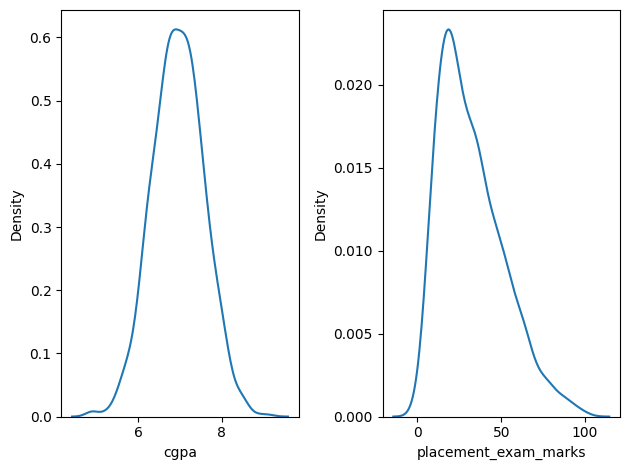

In [8]:
plt.subplot(1, 2, 1)
sns.kdeplot(df["cgpa"])

plt.subplot(1, 2, 2)
sns.kdeplot(df["placement_exam_marks"])

plt.tight_layout()
plt.show()

In [10]:
print("Mean:", df["cgpa"].mean())
print("SD:", df["cgpa"].std())
print("Min:", df["cgpa"].min())
print("Max", df["cgpa"].max())

Mean: 6.96124
SD: 0.6158978751323896
Min: 4.89
Max 9.12


In [11]:
# Finding the boundary values 
print("Highest Upper Bound:", df["cgpa"].mean() + 3 * df["cgpa"].std())
print("Lowest Upper Bound:", df["cgpa"].mean() - 3 * df["cgpa"].std())

Highest Upper Bound: 8.808933625397168
Lowest Upper Bound: 5.113546374602832


In [15]:
# Finding outliers 
df[(df["cgpa"] > 8.80) | (df["cgpa"] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [18]:
# Triming 
new_df = df[(df["cgpa"] < 8.80) & (df["cgpa"] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [19]:
# Approach 2 
# calculating z-score

df["cgpa_zscore"] = ((df["cgpa"] - df["cgpa"].mean()) / df["cgpa"].std())

In [20]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [22]:
df[(df["cgpa_zscore"] < -3) | (df["cgpa_zscore"] > 3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [23]:
# Trimming 
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]

In [24]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


Capping

In [25]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [26]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [27]:
df.shape

(1000, 4)

In [28]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64